In [43]:
import openai
import pandas as pd
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Filter, FieldCondition, MatchValue, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display
from typing import Literal, Any, Annotated, List, Dict
import random
from operator import add
from jinja2 import Template
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode
from langgraph.types import Send
import instructor
from langsmith import traceable, get_current_run_tree
from pydantic import Field

## Parallel Execution

In [31]:
qdrant_collection_name="Amazon-shopping-collection-01-hybrid-search"

In [48]:
class State(BaseModel):
    expanded_query: List[str] = []
    retreived_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str =""
    query: str = ""
    k: int = 10
    question_relevant: bool = False

In [49]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [50]:
@traceable(name = "query_expansion", run_type = "llm", metadata= {"ls_provider":"openai", "ls_model_name":"gpt-5.4-mini"})
def query_expansion_node(state: State) -> dict:
    prompt = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should capture a separate product or attribute from the query.
    - Use natural product-description language.
    - Do not produce multiple statements that express the same intent.

    ## Examples

    Question: "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Personal earphones"
    - "Waterproof speaker"

    Question: "I need a warm winter jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"

    Question: "Do you have any toys?"
    Statements:
    - "Toys"

    <question>
    {{ query }}
    </question>
    """

    jinja_template = Template(prompt)
    rendered_template = jinja_template.render(query = state.initial_query)
    client = instructor.from_provider("openai/gpt-5.4-mini", mode=instructor.Mode.RESPONSES_TOOLS)
    response = client.create(messages=[{"role": "system", "content": rendered_template}], 
                                reasoning={"effort": "none"},
                                response_model=QueryExpandResponse
                                )
    print(f"query_expansion_node: {response.statements}")
    return {
        "expanded_query": response.statements
    }



In [51]:
def query_expand_conditional_edges(state: State) -> dict:
    print(f"start send_message")
    send_messages = []
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    print(f"send_messages: {send_messages}")
    return send_messages

In [52]:
@traceable(name = "get_embedding", run_type = "embedding",metadata= {"ls_model_provider": "openai","ls_model_name": "text-embedding-3-small"})
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(input=text, model="text-embedding-3-small")
    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"]={
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens
        }
    return response.data[0].embedding

In [53]:
@traceable( name = "retrieve_data" , run_type="retriever")
def retriever_node(state: State) -> dict:
    print("after 0000000000000000")
    qdrant_client = QdrantClient(url="http://localhost:6333")
    hybrid = True
    query_embedding = get_embedding(state["query"])
    print("after embedding")
    if hybrid:
        # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            prefetch = [
                Prefetch(query = query_embedding, using = "text-embedding-3-small", limit = 20),
                Prefetch(query = Document(text=state["query"], model = "qdrant/bm25"), using = "bm25", limit = 20)
            ],
            query=models.RrfQuery(rrf = models.Rrf(weights=[3,1])),
            limit=state["k"])
    else:
         # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            query = query_embedding,
            using = "text-embedding-3-small",
            limit=state["k"])
    print("after 22222222222")
    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    print("after 333333333333")
    for pts in results.points:
        retrieved_context_ids.append(pts.payload['parent_asin'])
        retrieved_context.append(pts.payload['preprocessed_description'])
        similarity_scores.append(pts.score)
        retrieved_context_ratings.append(pts.payload['average_rating'])
    print("after 444444444444444")
    formated_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formated_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    print(f"retrieve_data: {formated_context}")
    return {
        "retreived_context" : [formated_context]
    }

In [54]:
class AggregatorResponse(BaseModel):
    answer: str


In [55]:
@traceable(name = "generate_answer", run_type = "llm", metadata= {"ls_provider":"openai", "ls_model_name":"gpt-5.4-mini"})
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retreived_context)
    
    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.

    You will be given a question and a list of context.

    ### Instructions

    - You need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

    ### Context

    {{ preprocessed_context }}

    ### Question

    {{ question }}
"""

    jinja_template = Template(prompt_template)
    rendered_template = jinja_template.render(preprocessed_context = preprocessed_context, question = state.initial_query)
    client = instructor.from_provider("openai/gpt-5.4-mini", mode=instructor.Mode.RESPONSES_TOOLS)
    response = client.create(messages=[{"role": "system", "content": rendered_template}], 
                                reasoning={"effort": "none"},
                                response_model=AggregatorResponse
                                )
    return {
        "answer": response.answer
    }

## User Intent Router Node

In [56]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if the users question is not relevant to the products.")

In [57]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

    ## Instructions

    - Determine whether the question is about products, inventory, or purchasing.
    - Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
    - Questions about store policies, personal advice, or unrelated topics are not relevant.

    ## Examples

    Question: "Do you have running shoes under $100?"
    Relevant: yes

    Question: "What's the weather like today?"
    Relevant: no - not related to products

    Question: "Can you help me write an essay?"
    Relevant: no - not related to products

    Question: "Which laptop has the best battery life?"
    Relevant: yes

    Question: "What's your return policy?"
    Relevant: no - about store policy, not product information

    <question>
    {{ query }}
    </question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=IntentRouterResponse
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }


In [59]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

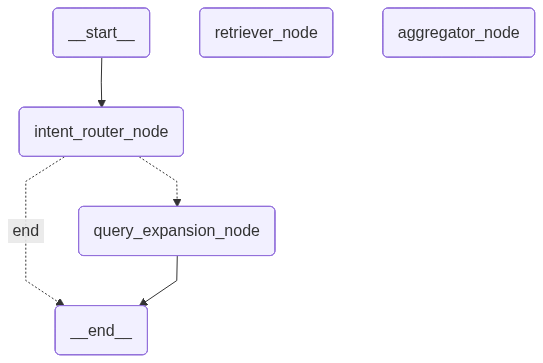

In [62]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
)
workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge(START, "intent_router_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
initial_state = {
    "initial_query": "give me steps to get to moon and buy earphones with wireless bluetooth?"
}

In [81]:
result = graph.invoke(initial_state)
result

query_expansion_node: ['Earphones with wireless Bluetooth', 'Moon travel steps or instructions']
start send_message
send_messages: [Send(node='retriever_node', arg={'query': 'Earphones with wireless Bluetooth', 'k': 10}), Send(node='retriever_node', arg={'query': 'Moon travel steps or instructions', 'k': 10})]
after 0000000000000000
after 0000000000000000
after embedding
after 22222222222
after 333333333333
after 444444444444444
retrieve_data: - ID: B09D8QFYPJ, rating: 4.5, description: Samsung Galaxy SmartTag Bluetooth Tracker (4 Pack, Multi Colors) EI-T5300KMEGWWTag it: Need to keep tabs on something, Attach a Galaxy SmartTag to those precious things in life. Find it: If you lost your stuff, just launch the app, and see where it’s been last. Retracing your steps is easy. Find it: If you lost your stuff, just launch the app, and see where it’s been last. Retracing your steps is easy. Take it easy: There it is. Thanks to Galaxy SmartTags, finding lost items is smart and simple. Use wit

{'expanded_query': ['Earphones with wireless Bluetooth',
  'Moon travel steps or instructions'],
 'retreived_context': ["- ID: B01KOE8D9Q, rating: 3.9, description: Sony MDRXB80BS/B Premium, Wireless, in-Ear, Sports Headphone, BlackSecure or easy fit with two-way wearing style.Connectivity Technology: Wireless Connect your device wirelessly with Bluetooth and NFC Splash-proof design that’s ready for rain or sweat Up to 7 hours of battery life with built-in rechargeable battery Precise-fitting hybrid silicone earbuds and arc supporters Built-in microphone and in-line remote for hands-free calls Compatible with Apple and Android smartphones With Carrying Pouch, Cable Adjustor and Clip\n- ID: B0BF4QS8ST, rating: 4.1, description: Wireless Earbuds, Touch Control Bluetooth 5.1 Headphones Built-in Microphone Noise Cancelling, IPX7 Waterproof Sport Earbuds, for iPhone Samsung Galaxy Fitness Earphone 48h Playtime(Upgraded Version)Truly wireless and ultra-light:Compact and ultra-lightweight, th